## Urban and Rural Area Classification for High-Resolution Climate Model Data

**Authors: Riddhima Puri, Claas Teichmann, Diana Rechid**

This notebook demonstrates the use of the urmask.py module containing UrbanRuralSelection class for generating urban and rural masks from convection-permitting regional climate model (CPRCM) data.

The framework here builds upon the concepts introduced in URCLIMASK (Diez-Sierra et al., 2025), which was developed for identifying urban areas in regional climate models. While the underlying philosophy remains the same—using the model's own land representation to define urban and rural areas—the methodology presented here extends the approach to the significantly greater spatial complexity of kilometre-scale simulations.

At resolutions of approximately 2-3 km, cities are no longer represented by a small number of grid cells. Instead, urban areas often appear as detailed spatial networks of urban cores, suburbs, industrial zones, and neighboring settlements. Under these conditions, neighboring towns and cities frequently become connected through corridors of low-density urban development, making it difficult to distinguish independent urban areas using a simple threshold-based approach alone.

To address this challenge, UrbanRuralSelection introduces several methodological developments beyond the original URCLIMASK framework:

- Multi-threshold urban-density analysis to improve separation of connected urban regions.
- Boundary-informed urban attribution to distinguish the target city from neighboring cities.
- Automated parameter selection and convergence criteria to reduce manual parameter tuning.
- Unique grid-cell assignment, ensuring that individual cells cannot belong to multiple cities.
- Optional rural-mask generation designed to support urban-rural comparisons for high-resolution climate applications.

Importantly, administrative boundaries are not used as simple clipping masks. Instead, they provide spatial context that helps identify which urban grid cells / connected urban areas belong to the target city while preserving the land-based representation of the underlying climate model.

A key advantage of this framework is that it minimizes the need to define city-specific parameter sets. Many parameters used during urban and rural selection can be determined dynamically from the characteristics of the target city and the underlying model data. This allows the methodology to adapt to both small and large urban areas without requiring extensive manual calibration. As a result, the workflow is more robust, transferable across regions, and produces masks that are more readily comparable between cities.

The resulting framework provides a largely plug-and-play workflow for creating urban and rural masks suitable for Urban Heat Island studies, city-to-city comparisons, climate services, and other urban-climate analyses. By combining model-based land representation with boundary-informed urban area selection, the methodology enables consistent urban definitions across diverse geographies while retaining the spatial detail available in modern kilometre-scale climate simulations.

**Workflow**

This notebook demonstrates how to:

1. Define a target city using an administrative or urban boundary polygon.
2. Crop climate-model datasets around the target city.
3. Generate an urban mask using urban fraction, land fraction, and optional terrain information.
4. Separate the target city from neighboring urban areas using boundary-informed attribution.
5. Optionally generate a surrounding rural mask.
6. Visualize and export the resulting masks as xarray datasets.

In [1]:
import numpy as np
import xarray as xr
import pandas as pd
import geopandas as gpd

In [2]:
from urmask.urmask import UrbanRuralSelection

In [ ]:
# Define root path
root = ''

### Load Model Data

In [4]:
# Loading REMO data
model = 'GERICS-REMO2020'
domain = 'CEU-3'
urban_file = f'{root}/data_joni_remo/EUC-0275_fractions_cmor.nc'
ds_urban = xr.open_dataset(urban_file).squeeze()

nukleus_root = '/work/ch1187/freva-regiklim/data/model/regional/all-nukleus/nukleus/data_NUKLEUS_CMOR/CEU-3/'

orog_file = nukleus_root + 'GERICS/MPI-M-MPI-ESM1-2-HR/historical/r1i1p1f1/GERICS-REMO2020/v1/fx/orog/v20240620/orog_CEU-3_MPI-M-MPI-ESM1-2-HR_historical_r1i1p1f1_GERICS-REMO2020_v1_fx.nc'
ds_orog = xr.open_dataset(orog_file).squeeze()

sftlf_file = nukleus_root + 'GERICS/MPI-M-MPI-ESM1-2-HR/historical/r1i1p1f1/GERICS-REMO2020/v1/fx/sftlf/v20240620/sftlf_CEU-3_MPI-M-MPI-ESM1-2-HR_historical_r1i1p1f1_GERICS-REMO2020_v1_fx.nc'
ds_sftlf = xr.open_dataset(sftlf_file).squeeze()

### Load Shapefile

In [5]:
# Load city polygon shapefile

# URAU
# https://gisco-services.ec.europa.eu/distribution/v2/urau/urau-2024-files.html
urau_file = 'URAU_RG_100K_2024_4326_CITIES.shp/URAU_RG_100K_2024_4326_CITIES.shp'
shape_file = f'{root}/shapefiles/{urau_file}'

# Load the shapefile containing city boundaries for the domain of interest or globally.
all_cities_gdf = gpd.read_file(shape_file)
# Column name in the shapefile that contains city names
column_city_names = 'URAU_NAME' 
# Assign a name for the dataset for metadata purposes
dataset_name = 'URAU'

In [6]:
# # UCDB
# # https://human-settlement.emergency.copernicus.eu/ghs_stat_ucdb2015mt_r2019a.php
# ucdb_file = 'GHS_UCDB_REGION_EUROPE_R2024A_V1_1/GHS_UCDB_REGION_EUROPE_R2024A.gpkg'
# shape_file = f'{root}/shapefiles/{ucdb_file}'

# # Load the shapefile containing city boundaries for the domain of interest or globally.
# all_cities_gdf = gpd.read_file(shape_file)
# # Column name in the shapefile that contains city names
# column_city_names = 'GC_UCN_MAI_2025'
# # Assign a name for the dataset for metadata purposes
# dataset_name = 'UCDB

In [7]:
all_cities_gdf

,URAU_CODE,URAU_CATG,CNTR_CODE,URAU_NAME,CITY_CPTL,FUA_CODE,AREA_SQM,NUTS3_2024,geometry
0,DK001C,C,DK,København,Y,DK001F,457.391971,DK011,"MULTIPOLYGON (((12.79255 55.60925, 12.79207 55..."
1,DE106C,C,DE,Bottrop,None,DE006F,100.248223,DEA31,"POLYGON ((6.8514 51.60716, 6.85111 51.6082, 6...."
2,DE107C,C,DE,Heilbronn,None,DE107F,100.623161,DE117,"POLYGON ((9.04451 49.19737, 9.04733 49.19765, ..."
3,DE108C,C,DE,Remscheid,None,DE108F,74.084072,DEA18,"POLYGON ((7.16635 51.15394, 7.1652 51.15402, 7..."
4,DK002C,C,DK,Århus,None,DK002F,473.050651,DK042,"POLYGON ((10.16613 56.29823, 10.17029 56.29944..."
...,...,...,...,...,...,...,...,...,...
734,SE002C,C,SE,Göteborg (greater city),None,SE002F,672.914083,SE232,"MULTIPOLYGON (((12.20291 57.82137, 12.20428 57..."
735,SE009C,C,SE,Södertälje,None,SE001F,611.035324,SE110,"MULTIPOLYGON (((17.35528 59.35222, 17.37279 59..."
736,SE010C,C,SE,Västerås,None,SE010F,1142.743200,SE125,"POLYGON ((16.46801 59.83931, 16.46852 59.83802..."
737,SE003C,C,SE,Malmö,None,SE003F,158.541248,SE224,"MULTIPOLYGON (((13.01319 55.63876, 13.01356 55..."


### Define UrbanRuralSelection Class

In [8]:
# Test cities
city_name = 'Berlin'
# city_name = 'Braunschweig'
# city_name = 'Wien'
# city_name = 'Essen'

In [9]:
UR = UrbanRuralSelection(
                       city_name=city_name, # Name of the city to create mask for. If does not match any city in the shapefile, the function will return an error.
                       all_cities_gdf=all_cities_gdf, # GeoDataFrame containing all city polygons (EPSG:4326).
                       gdf_column_city_names=column_city_names, # Column name in the GeoDataFrame that contains city names.

                       all_cities_gdf_short_name=dataset_name, # Short name for the dataset (e.g., 'URAU') for metadata purposes.
                       all_cities_gdf_long_name=urau_file, # Long name for the dataset (e.g., shapefile name) for metadata purposes.

                       resolution_km=(ds_urban.rlat[1] - ds_urban.rlat[0]).values * 111,  # Approximate conversion from degrees to km
                       model=model, # Model name for metadata purposes.
                       domain=domain, # Domain name for metadata purposes.

                       urban_threshold=0.1, # Threshold for urban fraction to classify a grid cell as urban. Default is 0.1 (10%).
                       rural_threshold=0.1, # Threshold for rural fraction to classify a grid cell as rural. Default is 0.1 (10%).
                       landsea_threshold=70, # Threshold for land-sea fraction to classify a grid cell as land. Default is 70 (%).
                       orography_diff=100, # Threshold for orography difference to classify a grid cell as urban. Default is 100 (m).
                       )

Berlin exists in column 'URAU_NAME' as 'Berlin'.


### Get city area

crop_city_area() function crops the input datasets to a smaller area around the bounding box of the city polygon -> such that, crop area = bounding box of the city polygon + crop_distance_from_city_polygon_km.

The user can specify the distance (in km) to crop around the city polygon, which will be determined in terms of the number of grid cells based on the resolution of the input datasets. 

If not specified, it will use half the distance of the bounding box of the city polygon as the default crop distance.

In [10]:
ds_uf_cropped = UR.crop_city_area(ds = ds_urban.urban,
                                #   crop_distance_from_city_polygon_km = 5
                                  )
ds_lf_cropped = UR.crop_city_area(ds = ds_sftlf['sftlf'],
                                    #   crop_distance_from_city_polygon_km = 5
                                      )
ds_orog_cropped = UR.crop_city_area(ds = ds_orog['orog'],
                                        # crop_distance_from_city_polygon_km = 5
                                        )

No 'crop_distance_from_city_polygon_km' provided. Cropping dataset to city polygon with buffer of 8 grid cells around the city polygon.
No 'crop_distance_from_city_polygon_km' provided. Cropping dataset to city polygon with buffer of 8 grid cells around the city polygon.
No 'crop_distance_from_city_polygon_km' provided. Cropping dataset to city polygon with buffer of 8 grid cells around the city polygon.


/work/ch0636/g300133/urban_mask/urmask/urmask.py:1209: UserWarning: Legend does not support handles for FeatureArtist instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  handles, labels = plt.gca().get_legend_handles_labels()


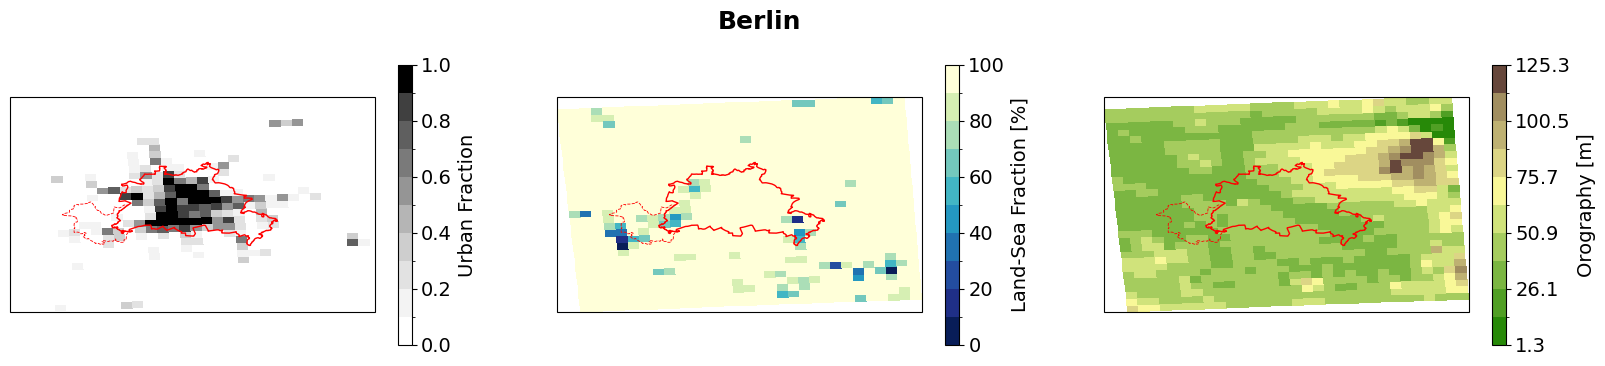

In [11]:
fig = UR.plot_variables_masks(ds_uf = ds_uf_cropped,
                           ds_lf = ds_lf_cropped,
                           ds_orog = ds_orog_cropped,
                           neighbors = True # Plot neighboring polygons of the selected city in the shapefile. Default is False.
                           )

### Compute Urban Mask

**Urban Mask Generation**

create_urban_mask() generates an (administratively meaningful) urban mask for a target city using urban-fraction, land-sea, and optionally orography datasets.

Unlike other urban-mask approaches that rely on a single urban-fraction threshold, this method uses multiple urban-density levels to improve the separation of the target city from nearby towns, satellite cities, and suburban developments. This is particularly important for high-resolution climate model data, where neighboring urban areas are often explicitly resolved and may appear as one continuous urban cluster.

If additional urban-fraction thresholds are not provided, they are derived dynamically from the urban-fraction distribution within the cropped domain.

To improve the separation of the target city from nearby towns and urban clusters, the algorithm can use multiple urban-fraction (UF) thresholds above the base urban_threshold. If no additional thresholds are provided, they are derived dynamically from the urban-fraction distribution of the cropped domain.

**Workflow**

1. *Create urban-density levels*: A binary mask is created for each urban-fraction threshold.
   - If additional thresholds are not provided by the user, they are estimated automatically using percentile-based tiers derived from the urban-fraction distribution. These levels represent increasing levels of urbanization.

   This multi-threshold approach helps distinguish dense urban cores from lower-density suburban regions that often connect to neighboring cities.

2. *Connected-component labeling*: For each urban-density level, connected urban regions are identified using connected-component labeling (scikit-image.measure.label).

   Each connected region is treated as a candidate urban cluster for further analysis.

3. *Component selection*:
   Each connected urban region is evaluated to determine whether it belongs to the target city or a neighboring urban area.

   Three situations can occur:

   A. Region intersects only the target city -> The entire region is retained.

   B. Region intersects only a neighboring city -> The entire region is discarded.

   C. Region intersects both the target city and a neighboring city -> A cell-by-cell assignment is performed to determine the city it most likely belongs to. Grid cells are assigned using the following hierarchical decision process:

      1. Whether the cell lies within (or very close to) a city's boundary, and is not lying in the neighbor cities. -> if True, keep, else move to 2.
      2. Whether the normalized distance to target city is smaller than that to neighbor cities. -> if True, keep, else if equidistant move to 3.
      3. Wehther distance from the cell to target city's centroid is smaller than that of neighbor cities. -> if True, keep, else if equidistant move to 4.
      4. Longitude of the city centroid as a final deterministic tie-break. -> if True, keep

    This procedure prevents urban-mask "leakage" into neighboring municipalities and ensures that urban grid cells are uniquely assigned to a single city.

4. *Construct urban mask*: Urban regions selected from all urban-density levels are combined using a logical OR operation to produce the final urban extent.

5. *Land-sea filtering*:
   The urban mask is restricted to grid cells whose land fraction exceeds the specified threshold. This ensures that only physically meaningful land points are retained.

6. *Optional orography filtering (Diez-Sierra (2025))*:
   Following the approach of Diez-Sierra et al. (2025), an elevation eligibility mask can optionally be generated.

   If enabled:

   - The minimum and maximum elevations within the identified urban area are determined.
   - The elevation range is expanded by the larger of:
      - the local terrain relief, or
      - the user-defined orography threshold.
   - Grid cells falling within the resulting elevation range are retained.

   This helps ensure that selected rural areas share similar topographic conditions to the urban area.

7. *Final urban mask*: The resulting urban mask is converted to a mask containing:

   - 1 for urban cells,
   - NaN for all other cells.

   The output is returned as an xarray dataset with appropriate metadata attached.

**Outputs**

The function returns:
- Urban mask
- Land-sea mask
- Orography mask (if generated)
- Connected-component labels
- Selected component labels

In [12]:
urban_mask, landsea_mask, orog_mask, labels, labels_sel = UR.create_urban_mask(ds_uf = ds_uf_cropped,
                                                                                ds_lf = ds_lf_cropped,
                                                                                ds_orog = ds_orog_cropped,
                                                                                # thresholds_fraction = [0.1, 0.5, 0.7],
                                                            )

Base percentile for urban threshold 0.1: 83.66%
Computed threshold percentiles: [83.65591398 91.82795699]
Dynamic thresholds for Berlin: [0.1        0.33333334]


/work/ch0636/g300133/urban_mask/urmask/urmask.py:1209: UserWarning: Legend does not support handles for FeatureArtist instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  handles, labels = plt.gca().get_legend_handles_labels()


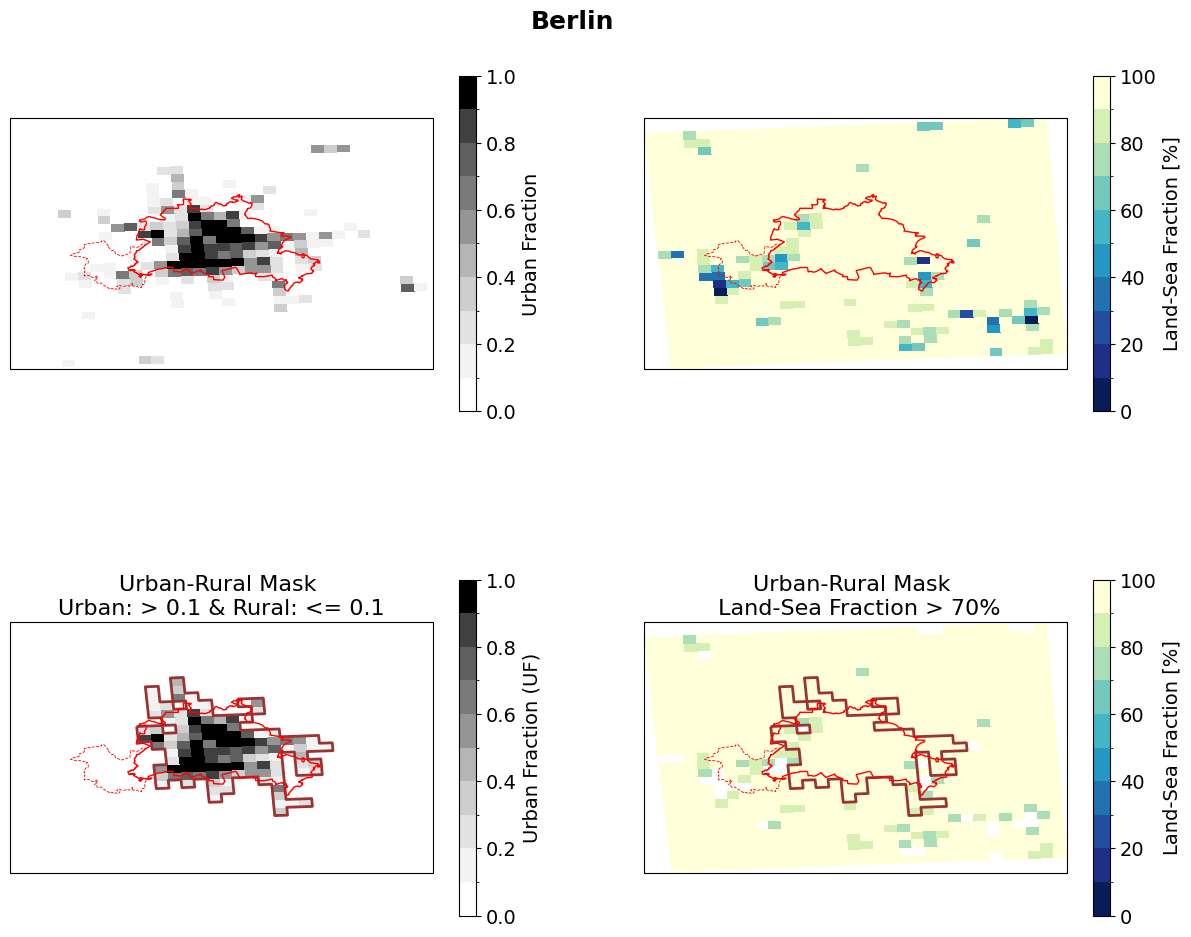

In [13]:
fig = UR.plot_variables_masks(ds_uf = ds_uf_cropped,
                           ds_lf = ds_lf_cropped,
                           urban_mask = urban_mask.urban_mask,
                           landsea_mask = landsea_mask,
                           neighbors = True,
                        #    urban_cmap = "inferno_r",
                        #    landsea_cmap = "winter",
                        #    orog_cmap = "viridis_r",
                        #    polygon_color = "#000000"
                        #    save_path = f'{root}/plots/urban_mask_{city_name}.png'
                        )

### Compute Rural Mask

**Rural Mask Generation**

create_rural_mask() generates a rural mask by expanding outward from the identified urban area and selecting nearby rural grid cells that satisfy user-defined criteria.

Building upon the rural-selection approach of Diez-Sierra et al. (2025), the methodology identifies rural grid cells that are spatially connected to the target city and representative of its surrounding environment rather than selecting rural areas from arbitrary locations within the model domain. This provides a consistent urban-rural comparison framework for Urban Heat Island (UHI) and other urban-climate analyses.

Moreover, the methodology here introduces an additional eligibility-screening step before mask growth begins. By first identifying all valid rural candidates, the algorithm can determine the maximum rural area available, set realistic growth targets, and establish robust convergence conditions before expansion starts. This improves stability and reduces sensitivity to domain size, city morphology, and user-defined parameters.


**Workflow**

1. *Seed initialization*: The urban mask generated by create_urban_mask() is converted into a boolean seed mask.

   This urban extent acts as the starting point from which the rural vicinity is identified.

2. *Eligible rural cell identification*: 

   Before any expansion occurs, the algorithm identifies all rural cells that are eligible for selection.

   Candidate cells must satisfy:

   - Urban fraction ≤ the specified rural_threshold,
   - Land-sea mask criteria,
   - Orography mask criteria (if enabled).

   This creates a constrained set of allowed rural cells and prevents the growth algorithm from repeatedly evaluating unsuitable locations during expansion.

3. *Optional city-boundary exclusion*: If requested, grid cells located within the city polygon can be excluded from the rural-selection process.

   This ensures that the rural mask represents the surrounding rural environment rather than low-density areas that may fall within the administrative boundary of the target city. 

4. *Define growth target and convergence criteria*:
   Using the pool of eligible rural cells identified in the previous step, the algorithm determines realistic growth targets before expansion begins.

   - Target rural cells = rural_to_urban_ratio × number of urban cells.
   - The target is automatically capped by the number of eligible rural cells available.

   Additional convergence criteria are established to ensure stable behavior across different cities and model domains:

   - A maximum expansion distance based on the cropped domain and grid resolution.
   - A stagnation criterion that terminates growth when no new eligible cells can be added.
   - Automatic recognition of situations where the requested rural area exceeds the available eligible rural area.

   Compared to the original implementation, this approach makes convergence more predictable and avoids unnecessary iterations when suitable rural cells are limited.

5. *Iterative rural expansion*:

   The rural vicinity is generated by iteratively expanding outward from the urban seed using morphological dilation.

   At each iteration, only previously identified eligible rural cells can be added to the mask.

   Expansion continues until:

   - The target rural-to-urban ratio is reached,
   - No additional eligible cells are available,
   - Or a predefined convergence criterion is met.

   This ensures that the selected rural area remains geographically connected to the target city while respecting the predefined land-cover and orography constraints.

6. *Final urban-rural mask*:
   The final mask is generated using the following convention:

   - 1 for urban cells
   - 0 for selected rural cells
   - NaN for all other cells

   The mask is returned as an xarray dataset with associated metadata.



In [14]:
urban_mask = UR.create_rural_mask(ds_uf = ds_uf_cropped,
                                     urban_mask = urban_mask.urban_mask.where(urban_mask.urban_mask == 1, 0),
                                     landsea_mask = landsea_mask,
                                     orog_mask = orog_mask,
                                    # rural_to_urban_ration = 1,
                                    # rural_area_inside_city_polygon=False
)


Iteration 1: non-urban cells = 65, urban cells = 118
Iteration 2: non-urban cells = 113, urban cells = 118
Iteration 3: non-urban cells = 162, urban cells = 118
Iteration 4: non-urban cells = 210, urban cells = 118
Iteration 5: non-urban cells = 265, urban cells = 118
Stopping... Reached rural/urban ratio criterion.


In [15]:
urban_mask

<xarray.Dataset> Size: 23kB
Dimensions:     (rlat: 30, rlon: 31)
Coordinates:
  * rlat        (rlat) float64 240B 1.444 1.471 1.499 ... 2.186 2.214 2.241
  * rlon        (rlon) float64 248B -3.199 -3.171 -3.144 ... -2.401 -2.374
    lat         (rlat, rlon) float64 7kB 52.08 52.08 52.08 ... 52.93 52.93 52.93
    lon         (rlat, rlon) float64 7kB 12.79 12.84 12.88 ... 13.97 14.02 14.06
    time        float64 8B 2.312e+05
Data variables:
    urban_mask  (rlat, rlon) float64 7kB nan nan nan nan nan ... nan nan nan nan
Attributes: (12/16)
    created_by:                                    UrbanSelection class in _u...
    description:                                   Dataset containing urban m...
    city_name:                                     Berlin
    all_cities_gdf_short_name:                     URAU
    all_cities_gdf_long_name:                      URAU_RG_100K_2024_4326_CIT...
    model:                                         GERICS-REMO2020
    ...                                            ...
    rural_area_urban_fraction_threshold:           0.1
    landsea_fraction_threshold:                    70
    orography_difference_threshold:                100
    crop_city_area_distance_from_city_polygon_km:  24.420000000000663
    rural_to_urban_ratio:                          2.0
    rural_area_inside_city_polygon:                True

/work/ch0636/g300133/urban_mask/urmask/urmask.py:1209: UserWarning: Legend does not support handles for FeatureArtist instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  handles, labels = plt.gca().get_legend_handles_labels()


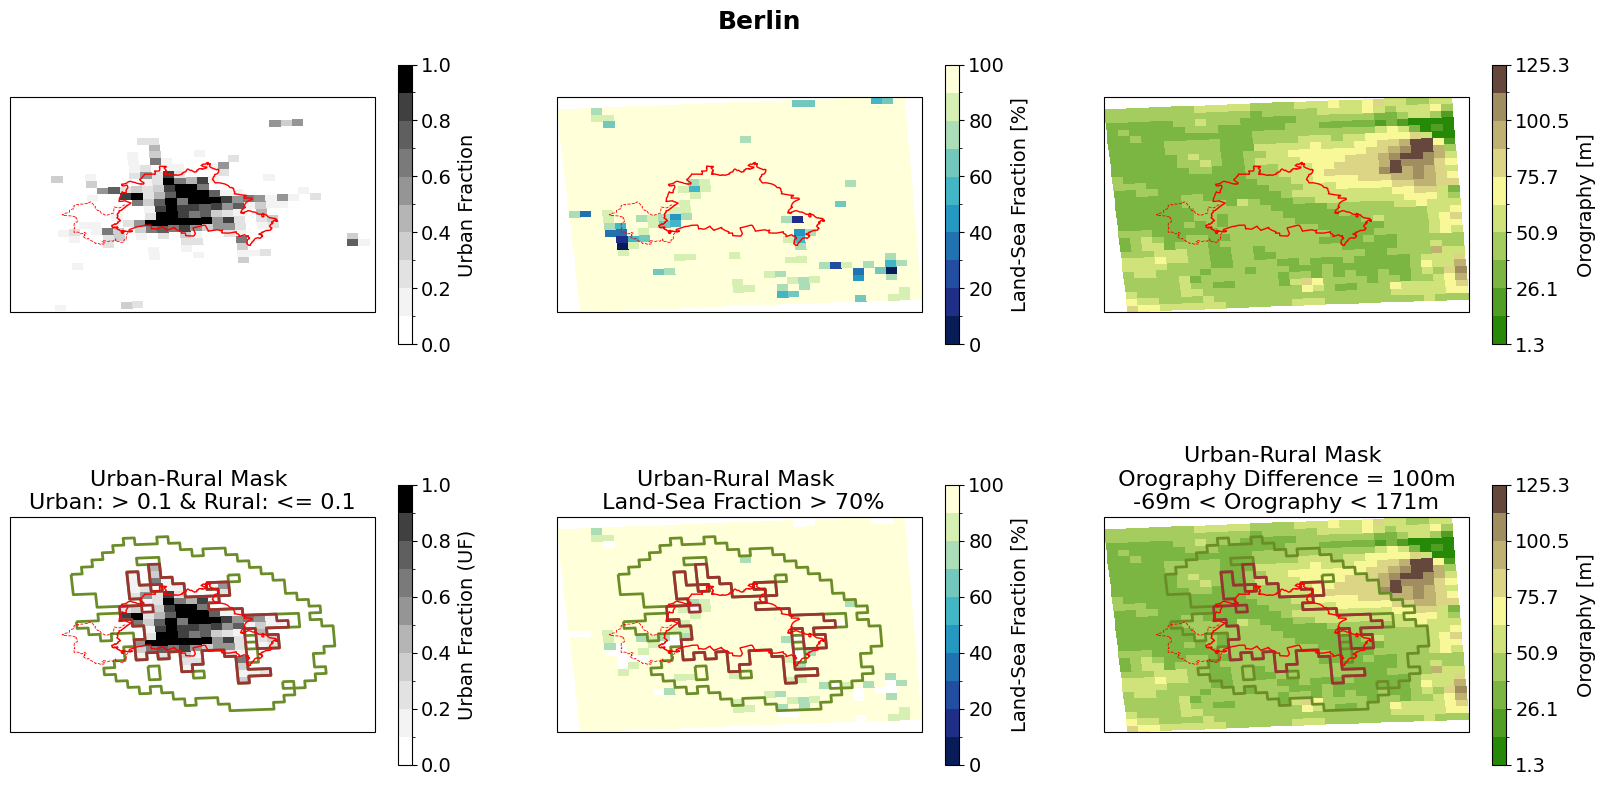

In [16]:
fig = UR.plot_variables_masks(ds_uf = ds_uf_cropped,
                           ds_lf = ds_lf_cropped,
                           ds_orog = ds_orog_cropped,
                           urban_mask = urban_mask.urban_mask,
                           landsea_mask = landsea_mask,
                           orog_mask = orog_mask,
                           neighbors = True
                        #    urban_cmap = "inferno_r",
                        #    landsea_cmap = "winter",
                        #    orog_cmap = "viridis_r",
                        #    polygon_color = "#000000"
                           # save_path = f'/work/ch0636/g300133/urban_mask/plots/{city_name}_urban_rural_mask.png'
                        )